In [ ]:
pip install requests beautifulsoup4


In [ ]:
import requests
from bs4 import BeautifulSoup
import csv

# Lista de URLs de las páginas web que deseas buscar
urls = ["https://www.crhoy.com/", "https://ameliarueda.com/", "https://semanariouniversidad.com/"]
palabras_clave = ["Presidente", "Chaves", "gobierno", "política"]

# Función para buscar noticias
def buscar_noticias(url, palabras_clave):
    respuesta = requests.get(url)
    soup = BeautifulSoup(respuesta.content, 'html.parser')

    # Aquí debes analizar la estructura HTML de cada página y encontrar cómo se listan las noticias
    # Ejemplo: noticias = soup.find_all('tag_html', class_='clase_css')
    noticias = soup.find_all('a')  # Esto es solo un ejemplo, debes ajustarlo

    for noticia in noticias:
        if any(palabra_clave in noticia.text for palabra_clave in palabras_clave):
            enlace = noticia.get('href')
            if enlace:
                yield url + enlace

# Guardar enlaces en un archivo CSV
with open('enlaces_noticias.csv', 'w', newline='', encoding='utf-8') as archivo:
    escritor = csv.writer(archivo)
    escritor.writerow(['Enlaces'])

    for url in urls:
        for enlace in buscar_noticias(url, palabras_clave):
            escritor.writerow([enlace])


In [ ]:
import requests
from bs4 import BeautifulSoup
import csv

# Suponiendo que tienes un archivo 'enlaces_noticias.csv' con los enlaces
enlaces_archivo = 'enlaces_noticias.csv'

# Función para extraer información de una noticia
def extraer_info_noticia(url):
    try:
        respuesta = requests.get(url)
        soup = BeautifulSoup(respuesta.content, 'html.parser')

        # Necesitas ajustar estos selectores a la estructura HTML específica de cada página
        titulo = soup.find('h1').get_text(strip=True)
        texto_noticia = ' '.join(p.get_text(strip=True) for p in soup.find_all('p'))
        fecha = soup.find('time').get_text(strip=True)  # Ajustar según sea necesario

        return [url, titulo, texto_noticia, fecha]
    except Exception as e:
        print(f"Error al procesar {url}: {e}")
        return [url, "Error", "Error", "Error"]

# Leer enlaces y procesar cada noticia
datos_noticias = []

with open(enlaces_archivo, 'r') as archivo:
    reader = csv.reader(archivo)
    next(reader, None)  # Saltar cabecera si existe
    for fila in reader:
        url = fila[0]
        datos_noticias.append(extraer_info_noticia(url))

# Escribir la información recolectada en un nuevo archivo CSV
with open('detalle_noticias.csv', 'w', newline='', encoding='utf-8') as archivo:
    escritor = csv.writer(archivo)
    escritor.writerow(['URL', 'Título', 'Texto', 'Fecha'])
    escritor.writerows(datos_noticias)


In [ ]:
pip install textblob


In [ ]:
from textblob import TextBlob
import csv

# Función para analizar el sentimiento
def analizar_sentimiento(texto):
    testimonio = TextBlob(texto)
    polaridad = testimonio.sentiment.polarity
    if polaridad > 0:
        return 'Positivo'
    elif polaridad < 0:
        return 'Negativo'
    else:
        return 'Neutro'

# Leer noticias y analizar sentimientos
with open('detalle_noticias.csv', 'r', encoding='utf-8') as archivo_entrada, \
     open('noticias_con_sentimiento.csv', 'w', newline='', encoding='utf-8') as archivo_salida:

    lector = csv.reader(archivo_entrada)
    escritor = csv.writer(archivo_salida)

    # Escribir cabecera
    cabecera = next(lector)
    escritor.writerow(cabecera + ['Sentimiento'])

    # Procesar cada fila
    for fila in lector:
        texto_noticia = fila[2]  # Asegúrate de que este índice sea correcto para el texto
        sentimiento = analizar_sentimiento(texto_noticia)
        escritor.writerow(fila + [sentimiento])


In [ ]:
import requests
from bs4 import BeautifulSoup
from textblob import TextBlob
import csv

# URLs de las páginas web que deseas buscar
urls = ["https://www.crhoy.com/", "https://ameliarueda.com/", "https://semanariouniversidad.com/"]
palabras_clave = ["Teletón", "Chaves", "gobierno", "política"]

# Función para buscar noticias
def buscar_noticias(url, palabras_clave):
    respuesta = requests.get(url)
    soup = BeautifulSoup(respuesta.content, 'html.parser')
    # Debes ajustar esta parte para cada sitio web
    noticias = soup.find_all('a')
    for noticia in noticias:
        if any(palabra_clave in noticia.text for palabra_clave in palabras_clave):
            enlace = noticia.get('href')
            if enlace:
                yield url + enlace

# Función para analizar el sentimiento
def analizar_sentimiento(texto):
    testimonio = TextBlob(texto)
    return 'Positivo' if testimonio.sentiment.polarity > 0 else 'Negativo' if testimonio.sentiment.polarity < 0 else 'Neutro'

# Función para extraer información de una noticia
def extraer_info_noticia(url):
    try:
        respuesta = requests.get(url)
        soup = BeautifulSoup(respuesta.content, 'html.parser')
        # Ajusta estos selectores a la estructura HTML de cada página
        titulo = soup.find('h1').get_text(strip=True)
        texto_noticia = ' '.join(p.get_text(strip=True) for p in soup.find_all('p'))
        fecha = soup.find('time').get_text(strip=True)
        sentimiento = analizar_sentimiento(texto_noticia)
        return [url, titulo, texto_noticia, fecha, sentimiento]
    except Exception as e:
        print(f"Error al procesar {url}: {e}")
        return [url, "Error", "Error", "Error", "Indeterminado"]

# Procesar cada sitio y cada noticia
datos_noticias = []
for url in urls:
    for enlace in buscar_noticias(url, palabras_clave):
        datos_noticias.append(extraer_info_noticia(enlace))

# Escribir la información recolectada en un archivo CSV
with open('noticias_con_sentimiento.csv', 'w', newline='', encoding='utf-8') as archivo:
    escritor = csv.writer(archivo)
    escritor.writerow(['URL', 'Título', 'Texto', 'Fecha', 'Sentimiento'])
    escritor.writerows(datos_noticias)


In [ ]:
pip install matplotlib pandas


In [ ]:
import requests
from bs4 import BeautifulSoup
from textblob import TextBlob
import csv
import pandas as pd
import matplotlib.pyplot as plt

# [Las funciones buscar_noticias, analizar_sentimiento y extraer_info_noticia van aquí]

# Procesar cada sitio y cada noticia
datos_noticias = []
for url in urls:
    for enlace in buscar_noticias(url, palabras_clave):
        datos_noticias.append(extraer_info_noticia(enlace))

# Guardar datos en un DataFrame de pandas
df_noticias = pd.DataFrame(datos_noticias, columns=['URL', 'Título', 'Texto', 'Fecha', 'Sentimiento'])

# Verificar que df_noticias no esté vacío
if not df_noticias.empty:
    # Conteo de sentimientos
    conteo_sentimientos = df_noticias['Sentimiento'].value_counts()

    # Verificar que hay datos para graficar
    if not conteo_sentimientos.empty:
        # Crear un gráfico de barras
        plt.figure(figsize=(8, 6))
        conteo_sentimientos.plot(kind='bar')
        plt.title('Distribución de Sentimientos en Noticias')
        plt.xlabel('Sentimiento')
        plt.ylabel('Cantidad')
        plt.xticks(rotation=0)
        plt.show()
    else:
        print("No hay datos de sentimientos para graficar.")
else:
    print("No hay datos en df_noticias.")



No hay datos en df_noticias.


In [ ]:
import requests
from bs4 import BeautifulSoup
from textblob import TextBlob
import csv
import pandas as pd
import matplotlib.pyplot as plt

# URLs de las páginas web que deseas buscar
urls = ["https://www.crhoy.com/", "https://ameliarueda.com/", "https://semanariouniversidad.com/"]
palabras_clave = ["Teletón", "Fueza", "Laboral", "empleados"]

# Función para buscar noticias
def buscar_noticias(url, palabras_clave):
    respuesta = requests.get(url)
    soup = BeautifulSoup(respuesta.content, 'html.parser')
    noticias = soup.find_all('a')
    for noticia in noticias:
        if any(palabra_clave in noticia.text for palabra_clave in palabras_clave):
            enlace = noticia.get('href')
            if enlace:
                yield url + enlace

# Función para analizar el sentimiento
def analizar_sentimiento(texto):
    testimonio = TextBlob(texto)
    return 'Positivo' if testimonio.sentiment.polarity > 0 else 'Negativo' if testimonio.sentiment.polarity < 0 else 'Neutro'

# Función para extraer información de una noticia
def extraer_info_noticia(url):
    try:
        respuesta = requests.get(url)
        soup = BeautifulSoup(respuesta.content, 'html.parser')
        titulo = soup.find('h1').get_text(strip=True)
        texto_noticia = ' '.join(p.get_text(strip=True) for p in soup.find_all('p'))
        fecha = soup.find('time').get_text(strip=True)
        sentimiento = analizar_sentimiento(texto_noticia)
        return [url, titulo, texto_noticia, fecha, sentimiento]
    except Exception as e:
        print(f"Error al procesar {url}: {e}")
        return [url, "Error", "Error", "Error", "Indeterminado"]

# Procesar cada sitio y cada noticia
datos_noticias = []
for url in urls:
    for enlace in buscar_noticias(url, palabras_clave):
        datos_noticias.append(extraer_info_noticia(enlace))

# Guardar datos en un DataFrame de pandas
df_noticias = pd.DataFrame(datos_noticias, columns=['URL', 'Título', 'Texto', 'Fecha', 'Sentimiento'])

# Verificar que df_noticias no esté vacío
if not df_noticias.empty:
    # Conteo de sentimientos
    conteo_sentimientos = df_noticias['Sentimiento'].value_counts()

    # Verificar que hay datos para graficar
    if not conteo_sentimientos.empty:
        # Crear un gráfico de barras
        plt.figure(figsize=(8, 6))
        conteo_sentimientos.plot(kind='bar')
        plt.title('Distribución de Sentimientos en Noticias')
        plt.xlabel('Sentimiento')
        plt.ylabel('Cantidad')
        plt.xticks(rotation=0)
        plt.show()
    else:
        print("No hay datos de sentimientos para graficar.")
else:
    print("No hay datos en df_noticias.")


No hay datos en df_noticias.


In [ ]:
import requests
from bs4 import BeautifulSoup
from textblob import TextBlob
import csv
import pandas as pd
import matplotlib.pyplot as plt

# URLs de las páginas web que deseas buscar
urls = ["https://www.crhoy.com/", "https://ameliarueda.com/", "https://semanariouniversidad.com/"]
palabras_clave = ["Teletón", "Fueza", "Laboral", "empleados"]

# Función para buscar noticias
def buscar_noticias(url, palabras_clave):
    respuesta = requests.get(url)
    soup = BeautifulSoup(respuesta.content, 'html.parser')
    noticias = soup.find_all('a')
    for noticia in noticias:
        if any(palabra_clave in noticia.text for palabra_clave in palabras_clave):
            enlace = noticia.get('href')
            if enlace:
                yield url + enlace

# Función para analizar el sentimiento
def analizar_sentimiento(texto):
    testimonio = TextBlob(texto)
    return 'Positivo' if testimonio.sentiment.polarity > 0 else 'Negativo' if testimonio.sentiment.polarity < 0 else 'Neutro'

# Función para extraer información de una noticia
def extraer_info_noticia(url):
    try:
        respuesta = requests.get(url)
        soup = BeautifulSoup(respuesta.content, 'html.parser')
        titulo = soup.find('h1').get_text(strip=True)
        texto_noticia = ' '.join(p.get_text(strip=True) for p in soup.find_all('p'))
        fecha = soup.find('time').get_text(strip=True)
        sentimiento = analizar_sentimiento(texto_noticia)
        return [url, titulo, texto_noticia, fecha, sentimiento]
    except Exception as e:
        print(f"Error al procesar {url}: {e}")
        return [url, "Error", "Error", "Error", "Indeterminado"]

# Procesar cada sitio y cada noticia
datos_noticias = []
for url in urls:
    enlaces = list(buscar_noticias(url, palabras_clave))
    print(f"Enlaces encontrados en {url}: {enlaces}")
    for enlace in enlaces:
        info_noticia = extraer_info_noticia(enlace)
        print(f"Información recolectada de {enlace}: {info_noticia}")
        datos_noticias.append(info_noticia)

# Guardar datos en un DataFrame de pandas
df_noticias = pd.DataFrame(datos_noticias, columns=['URL', 'Título', 'Texto', 'Fecha', 'Sentimiento'])
print("\nDataFrame con la información recolectada:")
print(df_noticias.head())  # Imprimir las primeras filas para verificar

# Verificar que df_noticias no esté vacío
if not df_noticias.empty:
    # Conteo de sentimientos
    conteo_sentimientos = df_noticias['Sentimiento'].value_counts()
    print("\nConteo de sentimientos:")
    print(conteo_sentimientos)

    # Verificar que hay datos para graficar
    if not conteo_sentimientos.empty:
        # Crear un gráfico de barras
        plt.figure(figsize=(8, 6))
        conteo_sentimientos.plot(kind='bar')
        plt.title('Distribución de Sentimientos en Noticias')
        plt.xlabel('Sentimiento')
        plt.ylabel('Cantidad')
        plt.xticks(rotation=0)
        plt.show()
    else:
        print("No hay datos de sentimientos para graficar.")
else:
    print("No hay datos en df_noticias.")


Enlaces encontrados en https://www.crhoy.com/: []
Enlaces encontrados en https://ameliarueda.com/: []
Enlaces encontrados en https://semanariouniversidad.com/: []

DataFrame con la información recolectada:
Empty DataFrame
Columns: [URL, Título, Texto, Fecha, Sentimiento]
Index: []
No hay datos en df_noticias.


Enlaces encontrados en https://www.crhoy.com/: []
Enlaces encontrados en https://ameliarueda.com/: []
Enlaces encontrados en https://semanariouniversidad.com/: ['https://semanariouniversidad.com/pais/terrenos-que-oficialismo-quiere-para-parque-del-agua-ya-habian-sido-limitados-para-la-conservacion-por-la-sala-iv/']
Información recolectada de https://semanariouniversidad.com/pais/terrenos-que-oficialismo-quiere-para-parque-del-agua-ya-habian-sido-limitados-para-la-conservacion-por-la-sala-iv/: ['https://semanariouniversidad.com/pais/terrenos-que-oficialismo-quiere-para-parque-del-agua-ya-habian-sido-limitados-para-la-conservacion-por-la-sala-iv/', 'Terrenos que oficialismo quiere para “parque del agua” ya habían sido limitados para la conservación por la Sala IV', 'PorVinicio Chacón Soto|[email\xa0protected] Hace más de 20 años, la Sala Constitucional determinó que los terrenos en Santa Ana que en la actualidad administra la Fundazoo deben dedicarse a la conservación del ambiente. Actua

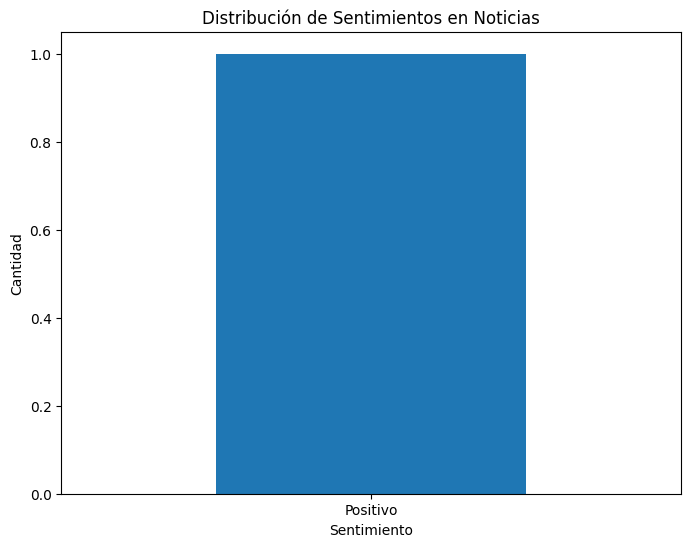

In [ ]:
import requests
from bs4 import BeautifulSoup
from textblob import TextBlob
import csv
import pandas as pd
import matplotlib.pyplot as plt

# URLs de las páginas web que deseas buscar
urls = ["https://www.crhoy.com/", "https://ameliarueda.com/", "https://semanariouniversidad.com/"]
palabras_clave = ["Agua", "Climático"]

# Función para buscar noticias
def buscar_noticias(url, palabras_clave):
    respuesta = requests.get(url)
    soup = BeautifulSoup(respuesta.content, 'html.parser')

    # Ajusta esta parte para cada sitio web según su estructura HTML
    noticias = soup.find_all('a')
    for noticia in noticias:
        texto_noticia = noticia.get_text(strip=True)
        enlace = noticia.get('href')
        if enlace and any(palabra_clave.lower() in texto_noticia.lower() for palabra_clave in palabras_clave):
            # Convertir a enlace absoluto si es necesario
            enlace_absoluto = enlace if enlace.startswith('http') else url.rstrip('/') + '/' + enlace.lstrip('/')
            yield enlace_absoluto

# Función para analizar el sentimiento
def analizar_sentimiento(texto):
    testimonio = TextBlob(texto)
    return 'Positivo' if testimonio.sentiment.polarity > 0 else 'Negativo' if testimonio.sentiment.polarity < 0 else 'Neutro'

# Función para extraer información de una noticia
def extraer_info_noticia(url):
    try:
        respuesta = requests.get(url)
        soup = BeautifulSoup(respuesta.content, 'html.parser')
        titulo = soup.find('h1').get_text(strip=True)
        texto_noticia = ' '.join(p.get_text(strip=True) for p in soup.find_all('p'))
        fecha = soup.find('time').get_text(strip=True)
        sentimiento = analizar_sentimiento(texto_noticia)
        return [url, titulo, texto_noticia, fecha, sentimiento]
    except Exception as e:
        print(f"Error al procesar {url}: {e}")
        return [url, "Error", "Error", "Error", "Indeterminado"]

# Procesar cada sitio y cada noticia
datos_noticias = []
for url in urls:
    enlaces = list(buscar_noticias(url, palabras_clave))
    print(f"Enlaces encontrados en {url}: {enlaces}")
    for enlace in enlaces:
        info_noticia = extraer_info_noticia(enlace)
        print(f"Información recolectada de {enlace}: {info_noticia}")
        datos_noticias.append(info_noticia)

# Guardar datos en un DataFrame de pandas
df_noticias = pd.DataFrame(datos_noticias, columns=['URL', 'Título', 'Texto', 'Fecha', 'Sentimiento'])
print("\nDataFrame con la información recolectada:")
print(df_noticias.head())  # Imprimir las primeras filas para verificar

# Verificar que df_noticias no esté vacío
if not df_noticias.empty:
    # Conteo de sentimientos
    conteo_sentimientos = df_noticias['Sentimiento'].value_counts()
    print("\nConteo de sentimientos:")
    print(conteo_sentimientos)

    # Verificar que hay datos para graficar
    if not conteo_sentimientos.empty:
        # Crear un gráfico de barras
        plt.figure(figsize=(8, 6))
        conteo_sentimientos.plot(kind='bar')
        plt.title('Distribución de Sentimientos en Noticias')
        plt.xlabel('Sentimiento')
        plt.ylabel('Cantidad')
        plt.xticks(rotation=0)
        plt.show()
    else:
        print("No hay datos de sentimientos para graficar.")
else:
    print("No hay datos en df_noticias.")


In [ ]:
import requests
from bs4 import BeautifulSoup
from textblob import TextBlob
import csv
import pandas as pd
import matplotlib.pyplot as plt

# URLs de las páginas web que deseas buscar
urls = ["https://www.crhoy.com/", "https://ameliarueda.com/", "https://semanariouniversidad.com/"]
palabras_clave = ["Fuerza Laboral", "Banco Nacional"]

# Función para buscar noticias
def buscar_noticias(url, palabras_clave):
    respuesta = requests.get(url)
    soup = BeautifulSoup(respuesta.content, 'html.parser')
    noticias = soup.find_all('a')
    for noticia in noticias:
        texto_noticia = noticia.get_text(strip=True)
        enlace = noticia.get('href')
        if enlace and any(palabra_clave.lower() in texto_noticia.lower() for palabra_clave in palabras_clave):
            enlace_absoluto = enlace if enlace.startswith('http') else url.rstrip('/') + '/' + enlace.lstrip('/')
            yield enlace_absoluto

# Función para extraer información de una noticia
def extraer_info_noticia(url):
    try:
        respuesta = requests.get(url)
        soup = BeautifulSoup(respuesta.content, 'html.parser')
        titulo = soup.find('h1').get_text(strip=True)
        texto_noticia = ' '.join(p.get_text(strip=True) for p in soup.find_all('p'))
        fecha = soup.find('time').get_text(strip=True)
        sentimiento = analizar_sentimiento(texto_noticia)
        return [url, titulo, texto_noticia, fecha, sentimiento]
    except Exception as e:
        print(f"Error al procesar {url}: {e}")
        return [url, "Error", "Error", "Error", "Indeterminado"]

# Función para analizar el sentimiento
def analizar_sentimiento(texto):
    testimonio = TextBlob(texto)
    return 'Positivo' if testimonio.sentiment.polarity > 0 else 'Negativo' if testimonio.sentiment.polarity < 0 else 'Neutro'

# Función para extraer comentarios de una noticia
def extraer_comentarios(url):
    try:
        respuesta = requests.get(url)
        soup = BeautifulSoup(respuesta.content, 'html.parser')
        # Ajusta esto según la estructura de los comentarios en el sitio web
        comentarios = soup.find_all('div', class_='clase-comentarios')
        texto_comentarios = [comentario.get_text(strip=True) for comentario in comentarios]
        return texto_comentarios
    except Exception as e:
        print(f"Error al extraer comentarios de {url}: {e}")
        return []

# Procesar cada sitio y cada noticia
datos_noticias = []
for url in urls:
    enlaces = list(buscar_noticias(url, palabras_clave))
    for enlace in enlaces:
        info_noticia = extraer_info_noticia(enlace)
        comentarios_noticia = extraer_comentarios(enlace)
        datos_noticias.append(info_noticia + [comentarios_noticia])

# Guardar datos en un DataFrame de pandas
df_noticias = pd.DataFrame(datos_noticias, columns=['URL', 'Título', 'Texto', 'Fecha', 'Sentimiento', 'Comentarios'])
print("\nDataFrame con la información recolectada:")
print(df_noticias.head())  # Imprimir las primeras filas para verificar

# Verificar que df_noticias no esté vacío
if not df_noticias.empty:
    # Conteo de sentimientos
    conteo_sentimientos = df_noticias['Sentimiento'].value_counts()
    print("\nConteo de sentimientos:")
    print(conteo_sentimientos)

    # Verificar que hay datos para graficar
    if not conteo_sentimientos.empty:
        # Crear un gráfico de barras
        plt.figure(figsize=(8, 6))
        conteo_sentimientos.plot(kind='bar')
        plt.title('Distribución de Sentimientos en Noticias')
        plt.xlabel('Sentimiento')
        plt.ylabel('Cantidad')
        plt.xticks(rotation=0)
        plt.show()
    else:
        print("No hay datos de sentimientos para graficar.")
else:
    print("No hay datos en df_noticias.")



DataFrame con la información recolectada:
Empty DataFrame
Columns: [URL, Título, Texto, Fecha, Sentimiento, Comentarios]
Index: []
No hay datos en df_noticias.


In [ ]:
import requests
from bs4 import BeautifulSoup
import csv

# URLs de las páginas web que deseas buscar
urls = ["https://www.crhoy.com/", "https://ameliarueda.com/", "https://semanariouniversidad.com/"]
palabras_clave = ["Fuerza Laboral", "Banco Nacional"]

# Función para buscar noticias
def buscar_noticias(url, palabras_clave):
    respuesta = requests.get(url)
    soup = BeautifulSoup(respuesta.content, 'html.parser')
    noticias = soup.find_all('a')
    for noticia in noticias:
        texto_noticia = noticia.get_text(strip=True)
        enlace = noticia.get('href')
        if enlace and any(palabra_clave.lower() in texto_noticia.lower() for palabra_clave in palabras_clave):
            enlace_absoluto = enlace if enlace.startswith('http') else url.rstrip('/') + '/' + enlace.lstrip('/')
            yield enlace_absoluto

# Función para extraer título de una noticia
def extraer_titulo_noticia(url):
    try:
        respuesta = requests.get(url)
        soup = BeautifulSoup(respuesta.content, 'html.parser')
        titulo = soup.find('h1').get_text(strip=True)
        return titulo
    except Exception as e:
        print(f"Error al extraer título de {url}: {e}")
        return "Error en el título"

# Función para extraer comentarios de una noticia
def extraer_comentarios(url):
    try:
        respuesta = requests.get(url)
        soup = BeautifulSoup(respuesta.content, 'html.parser')
        # Ajusta esto según la estructura de los comentarios en el sitio web
        comentarios = soup.find_all('div', class_='clase-comentarios')
        texto_comentarios = [comentario.get_text(strip=True) for comentario in comentarios]
        return texto_comentarios
    except Exception as e:
        print(f"Error al extraer comentarios de {url}: {e}")
        return []
# Recolectar y almacenar información y comentarios
datos_comentarios = []
for url in urls:
    enlaces = list(buscar_noticias(url, palabras_clave))
    for enlace in enlaces:
        titulo = extraer_titulo_noticia(enlace)
        comentarios = extraer_comentarios(enlace)
        for comentario in comentarios:
            datos_comentarios.append([enlace, titulo, comentario])
            print(f"URL: {enlace}, Título: {titulo}, Comentario: {comentario}")

# Escribir la información recolectada en un archivo CSV
with open('comentarios_noticias.csv', 'w', newline='', encoding='utf-8') as archivo:
    escritor = csv.writer(archivo)
    escritor.writerow(['URL', 'Título', 'Comentario'])
    escritor.writerows(datos_comentarios)


In [ ]:
import requests
from bs4 import BeautifulSoup
import csv

# URLs de las páginas web que deseas buscar
urls = ["https://www.crhoy.com/", "https://ameliarueda.com/", "https://semanariouniversidad.com/"]
palabras_clave = ["Fuerza Laboral", "Banco Nacional"]

# Función para buscar noticias
def buscar_noticias(url, palabras_clave):
    respuesta = requests.get(url)
    soup = BeautifulSoup(respuesta.content, 'html.parser')
    noticias = soup.find_all('a')
    for noticia in noticias:
        texto_noticia = noticia.get_text(strip=True)
        enlace = noticia.get('href')
        if enlace and any(palabra_clave.lower() in texto_noticia.lower() for palabra_clave in palabras_clave):
            enlace_absoluto = enlace if enlace.startswith('http') else url.rstrip('/') + '/' + enlace.lstrip('/')
            yield enlace_absoluto

# Función para extraer título de una noticia
def extraer_titulo_noticia(url):
    try:
        respuesta = requests.get(url)
        soup = BeautifulSoup(respuesta.content, 'html.parser')
        titulo = soup.find('h1').get_text(strip=True)
        return titulo
    except Exception as e:
        print(f"Error al extraer título de {url}: {e}")
        return "Error en el título"

# Función para extraer comentarios de una noticia
def extraer_comentarios(url):
    try:
        respuesta = requests.get(url)
        soup = BeautifulSoup(respuesta.content, 'html.parser')
        # Ajusta esto según la estructura de los comentarios en el sitio web
        comentarios = soup.find_all('div', class_='clase-comentarios')
        texto_comentarios = [comentario.get_text(strip=True) for comentario in comentarios]
        return texto_comentarios
    except Exception as e:
        print(f"Error al extraer comentarios de {url}: {e}")
        return []

# Recolectar y almacenar información y comentarios
datos_comentarios = []
for url in urls:
    enlaces = list(buscar_noticias(url, palabras_clave))
    for enlace in enlaces:
        titulo = extraer_titulo_noticia(enlace)
        comentarios = extraer_comentarios(enlace)
        for comentario in comentarios[:5]:  # Limitar a los primeros 5 comentarios para la impresión
            datos_comentarios.append([enlace, titulo, comentario])
            print(f"URL: {enlace}, Título: {titulo}, Comentario: {comentario}")

# Escribir la información recolectada en un archivo CSV
with open('comentarios_noticias.csv', 'w', newline='', encoding='utf-8') as archivo:
    escritor = csv.writer(archivo)
    escritor.writerow(['URL', 'Título', 'Comentario'])
    escritor.writerows(datos_comentarios)

# Leer y mostrar el contenido del archivo CSV
print("\nContenido del archivo CSV:")
df = pd.read_csv('comentarios_noticias.csv')
print(df)



Contenido del archivo CSV:
Empty DataFrame
Columns: [URL, Título, Comentario]
Index: []


In [ ]:
import requests
from bs4 import BeautifulSoup
from textblob import TextBlob
import csv
import pandas as pd
import matplotlib.pyplot as plt

# URLs de las páginas web que deseas buscar
urls = ["https://www.crhoy.com/", "https://ameliarueda.com/", "https://semanariouniversidad.com/"]
palabras_clave = ["Fuerza Laboral", "Banco Nacional"]

# Función para buscar noticias
def buscar_noticias(url, palabras_clave):
    respuesta = requests.get(url)
    soup = BeautifulSoup(respuesta.content, 'html.parser')
    noticias = soup.find_all('a')
    for noticia in noticias:
        texto_noticia = noticia.get_text(strip=True)
        enlace = noticia.get('href')
        if enlace and any(palabra_clave.lower() in texto_noticia.lower() for palabra_clave in palabras_clave):
            enlace_absoluto = enlace if enlace.startswith('http') else url.rstrip('/') + '/' + enlace.lstrip('/')
            yield enlace_absoluto

# Función para extraer información de una noticia
def extraer_info_noticia(url):
    try:
        respuesta = requests.get(url)
        soup = BeautifulSoup(respuesta.content, 'html.parser')
        titulo = soup.find('h1').get_text(strip=True)
        texto_noticia = ' '.join(p.get_text(strip=True) for p in soup.find_all('p'))
        fecha = soup.find('time').get_text(strip=True)
        sentimiento = analizar_sentimiento(texto_noticia)
        return [url, titulo, texto_noticia, fecha, sentimiento]
    except Exception as e:
        print(f"Error al procesar {url}: {e}")
        return [url, "Error", "Error", "Error", "Indeterminado"]

# Función para analizar el sentimiento
def analizar_sentimiento(texto):
    testimonio = TextBlob(texto)
    return 'Positivo' if testimonio.sentiment.polarity > 0 else 'Negativo' if testimonio.sentiment.polarity < 0 else 'Neutro'

# Función para extraer comentarios de una noticia
def extraer_comentarios(url):
    try:
        respuesta = requests.get(url)
        soup = BeautifulSoup(respuesta.content, 'html.parser')
        comentarios = soup.find_all('div', class_='clase-comentarios')
        texto_comentarios = [comentario.get_text(strip=True) for comentario in comentarios]
        return texto_comentarios
    except Exception as e:
        print(f"Error al extraer comentarios de {url}: {e}")
        return []

# Procesar cada sitio y cada noticia
datos_noticias = []
datos_comentarios = []
for url in urls:
    enlaces = list(buscar_noticias(url, palabras_clave))
    for enlace in enlaces:
        info_noticia = extraer_info_noticia(enlace)
        datos_noticias.append(info_noticia)
        comentarios_noticia = extraer_comentarios(enlace)
        for comentario in comentarios_noticia[:5]:  # Limitar a los primeros 5 comentarios
            datos_comentarios.append([enlace, info_noticia[1], comentario])  # URL, Título, Comentario

# Guardar datos de noticias en un DataFrame y en un archivo CSV
df_noticias = pd.DataFrame(datos_noticias, columns=['URL', 'Título', 'Texto', 'Fecha', 'Sentimiento'])
df_noticias.to_csv('noticias.csv', index=False)

# Guardar datos de comentarios en un archivo CSV
with open('comentarios_noticias.csv', 'w', newline='', encoding='utf-8') as archivo:
    escritor = csv.writer(archivo)
    escritor.writerow(['URL', 'Título', 'Comentario'])
    escritor.writerows(datos_comentarios)

# Leer y mostrar el contenido de los archivos CSV
print("\nContenido del archivo CSV de noticias:")
print(pd.read_csv('noticias.csv').head())

print("\nContenido del archivo CSV de comentarios:")
print(pd.read_csv('comentarios_noticias.csv').head())


Error al procesar https://semanariouniversidad.com/pais/empleados-del-banco-nacional-pagaron-%e2%82%a111-718-millones-de-su-ahorro-para-asumir-perdidas-por-caso-asebanacio/: 'NoneType' object has no attribute 'get_text'
Error al procesar https://semanariouniversidad.com/pais/empleados-del-banco-nacional-pagaron-%e2%82%a111-718-millones-de-su-ahorro-para-asumir-perdidas-por-caso-asebanacio/: 'NoneType' object has no attribute 'get_text'
Error al procesar https://semanariouniversidad.com/pais/empleados-del-banco-nacional-pagaron-%e2%82%a111-718-millones-de-su-ahorro-para-asumir-perdidas-por-caso-asebanacio/: 'NoneType' object has no attribute 'get_text'

Contenido del archivo CSV de noticias:
                                                 URL  \
0  https://semanariouniversidad.com/pais/fuerza-l...   
1  https://semanariouniversidad.com/pais/fuerza-l...   
2  https://semanariouniversidad.com/pais/empleado...   
3  https://semanariouniversidad.com/pais/empleado...   
4  https://semanario